In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, accuracy_score, roc_auc_score

In [170]:
df = pd.read_csv('new_one.csv')

In [171]:
# add dummies for room type
prop_type_dummies = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
# add dummies to the main dataframe
df = pd.concat([df, prop_type_dummies], axis=1)

room_type_params = list(prop_type_dummies.columns)[:-1]

df = df.loc[:, ~df.columns.duplicated()]

In [172]:
# define variables for initial model
# parameters of property characteristics
prop_params = ['bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'instant_bookable', 'price', 'accommodates'] 
prop_params += room_type_params

# parameters of host characteristics
host_params = ['host_total_listings_count', 'host_tenure_days', 'host_is_superhost']

# parameters of reviews characteristics
reviews_params = ['number_of_reviews', 'review_scores_rating', 'reviews_last_year', 'reviews_per_month']

# parameters of location characteristics
loc_params = ['distance_to_city_center']

In [173]:
parameters = prop_params + host_params + reviews_params + loc_params

In [174]:
X = df[parameters]
y = df['occupancy'] 
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     42.00
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          5.01e-144
Time:                        20:57:59   Log-Likelihood:                -3395.7
No. Observations:               11795   AIC:                             6829.
Df Residuals:                   11776   BIC:                             6970.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [175]:
aic = {}
y = df["occupancy"]
parameters = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[parameters]
    x = sm.add_constant(x)
    model_current = sm.OLS(y, x).fit()
    aic["baseline"] =  model_current.aic
    for col in df[parameters]:
        y = df["occupancy"]
        candidate_params = parameters.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.OLS(y, x).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        parameters.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df

,excluded_variable,p_value_at_excluding,AIC_before,AIC_after
0,number_of_reviews,0.945125,6829.450728,6827.455473
1,reviews_per_month,0.698081,6827.455473,6825.606185
2,bathrooms,0.238289,6825.606185,6824.998937


In [176]:
X = df[parameters]
y = df['occupancy']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     50.30
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          3.12e-146
Time:                        20:58:00   Log-Likelihood:                -3396.5
No. Observations:               11795   AIC:                             6825.
Df Residuals:                   11779   BIC:                             6943.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [177]:
occupancy_ols_model = model

In [178]:
parameters = prop_params + host_params + reviews_params + loc_params

In [179]:

X = df[parameters]
X = sm.add_constant(X)

model = sm.GLM(
    df['occupancy'],
    X,
    family=sm.families.Binomial()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              occupancy   No. Observations:                11795
Model:                            GLM   Df Residuals:                    11776
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6348.1
Date:                Wed, 08 Apr 2026   Deviance:                       6003.2
Time:                        20:58:00   Pearson chi2:                 5.15e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02775
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [180]:
aic = {}
y = df["occupancy"]
parameters = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[parameters]
    x = sm.add_constant(x)
    model_current = sm.GLM(y, x, family=sm.families.Binomial()).fit()
    aic["baseline"] =  model_current.aic
    for col in df[parameters]:
        y = df["occupancy"]
        candidate_params = parameters.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.GLM(y, x, family=sm.families.Binomial()).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        parameters.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df

,excluded_variable,p_value_at_excluding,AIC_before,AIC_after
0,number_of_reviews,0.971738,12734.212841,12732.214096
1,reviews_per_month,0.831415,12732.214096,12730.259337
2,bathrooms,0.431521,12730.259337,12728.880187
3,host_is_superhost,0.210467,12728.880187,12728.448973
4,distance_to_city_center,0.161489,12728.448973,12728.415900


In [181]:

X = df[parameters]
X = sm.add_constant(X)

model = sm.GLM(
    df['occupancy'],
    X,
    family=sm.families.Binomial()
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              occupancy   No. Observations:                11795
Model:                            GLM   Df Residuals:                    11781
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6350.2
Date:                Wed, 08 Apr 2026   Deviance:                       6007.4
Time:                        20:58:04   Pearson chi2:                 5.15e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02740
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [182]:
occupancy_glm_model= model

In [183]:
df['high_occupancy'] = (df['occupancy'] > df['occupancy'].median()).astype(int)

In [184]:
parameters = prop_params + host_params + reviews_params + loc_params

In [185]:
# logit model with high_occupancy as target variable
X = df[parameters]
y = df['high_occupancy']
X = sm.add_constant(X)
model_logit = sm.Logit(y, X).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.671346
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         high_occupancy   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11776
Method:                           MLE   Df Model:                           18
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.03145
Time:                        20:58:04   Log-Likelihood:                -7918.5
converged:                       True   LL-Null:                       -8175.7
Covariance Type:            nonrobust   LLR p-value:                 1.051e-97
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.5887      0.386     -4.119      0.000      -2.

In [186]:
aic = {}
y = df["high_occupancy"]
parameters = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[parameters]
    x = sm.add_constant(x)
    model_current = sm.Logit(y, x).fit()
    aic["baseline"] =  model_current.aic
    for col in df[parameters]:
        y = df["occupancy"]
        candidate_params = parameters.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.Logit(y, x).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        parameters.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df

Optimization terminated successfully.
         Current function value: 0.671346
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656150
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.657529
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656409
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.658247
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.659671
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.658379
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.657157
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656368
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.656217
  

,excluded_variable,p_value_at_excluding,AIC_before,AIC_after
0,number_of_reviews,0.494540,15875.055036,15513.613068
1,reviews_per_month,0.831415,15513.613068,15511.818691
2,bathrooms,0.431521,15511.818691,15510.803758


In [187]:
X = df[parameters]
y = df['high_occupancy']
X = sm.add_constant(X)
model_logit = sm.Logit(y, X).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.671452
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         high_occupancy   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11779
Method:                           MLE   Df Model:                           15
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.03130
Time:                        20:58:06   Log-Likelihood:                -7919.8
converged:                       True   LL-Null:                       -8175.7
Covariance Type:            nonrobust   LLR p-value:                 1.853e-99
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.6436      0.384     -4.280      0.000      -2.

In [188]:
occupancy_logit_model = model_logit

In [189]:
df["p_hat"] = model_logit.predict(X)
df["high_occupancy_pred"] = (df["p_hat"] >= 0.5).astype(int)

cm = confusion_matrix(df["high_occupancy"], df["high_occupancy_pred"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix:")
display(cm_df)

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3503,2405
Actual 1,2414,3473


In [190]:
accuracy = accuracy_score(df["high_occupancy"], df["high_occupancy_pred"])
sensativity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Sensitivity", "Specificity"],
    "Value": [accuracy, sensativity, specificity]
})

display(metrics_df.round(4))

,Metric,Value
0,Accuracy,0.5914
1,Sensitivity,0.5899
2,Specificity,0.5929


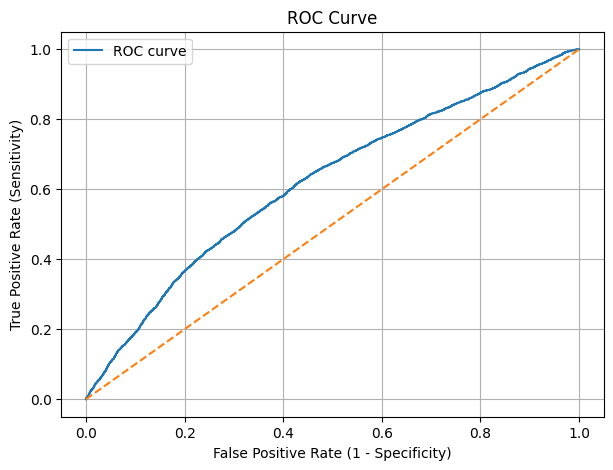

In [191]:
y_true = df["high_occupancy"]
y_score = df["p_hat"]

fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [192]:

auc = roc_auc_score(df["high_occupancy"], df["p_hat"])
print(f"AUC: {auc:.4f}")

AUC: 0.6193


In [193]:
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print("Optimal threshold by Youden's J:", best_threshold)

Optimal threshold by Youden's J: 0.4896025205509918


In [194]:
df["p_hat"] = model_logit.predict(X)
df["high_occupancy_pred_best"] = (df["p_hat"] >= best_threshold).astype(int)

cm_best = confusion_matrix(df["high_occupancy"], df["high_occupancy_pred_best"])

cm_df_best = pd.DataFrame(
    cm_best,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
print("Old Confusion Matrix:")
display(cm_df)
print("Confusion Matrix:")
display(cm_df_best)

Old Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3503,2405
Actual 1,2414,3473


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,3341,2567
Actual 1,2217,3670


In [195]:
print("HYPOTHESIS TESTS: OCCUPANCY OLS MODEL")

print(occupancy_ols_model.summary())

HYPOTHESIS TESTS: OCCUPANCY OLS MODEL
                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     50.30
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          3.12e-146
Time:                        20:58:06   Log-Likelihood:                -3396.5
No. Observations:               11795   AIC:                             6825.
Df Residuals:                   11779   BIC:                             6943.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [196]:
# H a: higher price reduces occupancy
if 'price' in occupancy_ols_model.params.index:
    print("\nH1: Price affects occupancy")
    print(occupancy_ols_model.t_test("price = 0"))


H1: Price affects occupancy
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0          5.158e-05   5.69e-06      9.060      0.000    4.04e-05    6.27e-05


In [197]:
# H b: booking friction
booking_vars = ['minimum_nights', 'instant_bookable']
booking_vars_ols = [v for v in booking_vars if v in occupancy_ols_model.params.index]

if 'minimum_nights' in occupancy_ols_model.params.index:
    print("\nH1: Minimum nights affects occupancy")
    print(occupancy_ols_model.t_test("minimum_nights = 0"))

if 'instant_bookable' in occupancy_ols_model.params.index:
    print("\nH1: Instant bookable affects occupancy")
    print(occupancy_ols_model.t_test("instant_bookable = 0"))

if booking_vars_ols:
    restriction = " = 0, ".join(booking_vars_ols) + " = 0"
    print("\nH1: Booking variables jointly affect occupancy")
    print(occupancy_ols_model.f_test(restriction))


H1: Minimum nights affects occupancy
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0012      0.000     -8.515      0.000      -0.001      -0.001

H1: Instant bookable affects occupancy
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0742      0.007    -11.398      0.000      -0.087      -0.061

H1: Booking variables jointly affect occupancy
<F test: F=95.43165504804749, p=7.70476951522152e-42, df_denom=1.18e+04, df_num=2>


In [198]:
# H c: reputation and social proof
rep_vars = ['host_is_superhost', 'reviews_last_year', 'review_scores_rating', 'reviews_per_month']
rep_vars_ols = [v for v in rep_vars if v in occupancy_ols_model.params.index]

for var in ['host_is_superhost', 'reviews_last_year', 'review_scores_rating']:
    if var in occupancy_ols_model.params.index:
        print(f"\nH1: {var} affects occupancy")
        print(occupancy_ols_model.t_test(f"{var} = 0"))

if rep_vars_ols:
    restriction = " = 0, ".join(rep_vars_ols) + " = 0"
    print("\nH1 joint: Reputation variables affect occupancy")
    print(occupancy_ols_model.f_test(restriction))


H1: host_is_superhost affects occupancy
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0134      0.007     -1.934      0.053      -0.027       0.000

H1: reviews_last_year affects occupancy
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0005      0.000     -3.546      0.000      -0.001      -0.000

H1: review_scores_rating affects occupancy
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0   

In [199]:
print("HYPOTHESIS TESTS: OCCUPANCY GLM MODEL")

print(occupancy_glm_model.summary())


HYPOTHESIS TESTS: OCCUPANCY GLM MODEL
                 Generalized Linear Model Regression Results                  
Dep. Variable:              occupancy   No. Observations:                11795
Model:                            GLM   Df Residuals:                    11781
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6350.2
Date:                Wed, 08 Apr 2026   Deviance:                       6007.4
Time:                        20:58:06   Pearson chi2:                 5.15e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02740
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [200]:

if 'price' in occupancy_glm_model.params.index:
    print("\nH1: Price affects occupancy")
    print(occupancy_glm_model.t_test("price = 0"))


H1: Price affects occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0002   3.49e-05      6.384      0.000       0.000       0.000


In [201]:

booking_vars_glm = [v for v in ['minimum_nights', 'instant_bookable'] if v in occupancy_glm_model.params.index]

if 'minimum_nights' in occupancy_glm_model.params.index:
    print("\nH1: Minimum nights affects occupancy")
    print(occupancy_glm_model.t_test("minimum_nights = 0"))

if 'instant_bookable' in occupancy_glm_model.params.index:
    print("\nH1: Instant bookable affects occupancy")
    print(occupancy_glm_model.t_test("instant_bookable = 0"))

if booking_vars_glm:
    restriction = " = 0, ".join(booking_vars_glm) + " = 0"
    print("\nH1: Booking variables jointly affect occupancy")
    print(occupancy_glm_model.wald_test(restriction))


H1: Minimum nights affects occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0056      0.001     -5.441      0.000      -0.008      -0.004

H1: Instant bookable affects occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.2999      0.041     -7.277      0.000      -0.381      -0.219

H1: Booking variables jointly affect occupancy
<Wald test (chi2): statistic=[[77.01499543]], p-value=1.8897581697875727e-17, df_denom=2>


c:\Users\justy\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [202]:
rep_vars_glm = [v for v in ['host_is_superhost', 'reviews_last_year', 'review_scores_rating', 'reviews_per_month']
                if v in occupancy_glm_model.params.index]

for var in ['host_is_superhost', 'reviews_last_year', 'review_scores_rating']:
    if var in occupancy_glm_model.params.index:
        print(f"\nH1: {var} affects occupancy")
        print(occupancy_glm_model.t_test(f"{var} = 0"))

if rep_vars_glm:
    restriction = " = 0, ".join(rep_vars_glm) + " = 0"
    print("\nH1 joint: Reputation variables affect occupancy")
    print(occupancy_glm_model.wald_test(restriction))


H1: reviews_last_year affects occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0027      0.001     -2.747      0.006      -0.005      -0.001

H1: review_scores_rating affects occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.1677      0.059      2.861      0.004       0.053       0.283

H1 joint: Reputation variables affect occupancy
<Wald test (chi2): statistic=[[14.93121142]], p-value=0.000572438236359936, df_denom=2>


In [203]:
print("HYPOTHESIS TESTS: OCCUPANCY LOGIT MODEL")

print(occupancy_logit_model.summary())


HYPOTHESIS TESTS: OCCUPANCY LOGIT MODEL
                           Logit Regression Results                           
Dep. Variable:         high_occupancy   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11779
Method:                           MLE   Df Model:                           15
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.03130
Time:                        20:58:06   Log-Likelihood:                -7919.8
converged:                       True   LL-Null:                       -8175.7
Covariance Type:            nonrobust   LLR p-value:                 1.853e-99
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.6436      0.384     -4.280      0.000      -2.396      -0.891
bedrooms                      0.1869      0.03

In [204]:
if 'price' in occupancy_logit_model.params.index:
    print("\nH1: Price affects probability of high occupancy")
    print(occupancy_logit_model.t_test("price = 0"))


H1: Price affects probability of high occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0003   3.63e-05      8.515      0.000       0.000       0.000


In [205]:
booking_vars_logit = [v for v in ['minimum_nights', 'instant_bookable'] if v in occupancy_logit_model.params.index]

if 'minimum_nights' in occupancy_logit_model.params.index:
    print("\nH1: Minimum nights affects probability of high occupancy")
    print(occupancy_logit_model.t_test("minimum_nights = 0"))

if 'instant_bookable' in occupancy_logit_model.params.index:
    print("\nH1: Instant bookable affects probability of high occupancy")
    print(occupancy_logit_model.t_test("instant_bookable = 0"))

if booking_vars_logit:
    restriction = " = 0, ".join(booking_vars_logit) + " = 0"
    print("\nH1: Booking variables jointly affect probability of high occupancy")
    print(occupancy_logit_model.wald_test(restriction))


H1: Minimum nights affects probability of high occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0053      0.001     -5.418      0.000      -0.007      -0.003

H1: Instant bookable affects probability of high occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.3948      0.041     -9.591      0.000      -0.475      -0.314

H1: Booking variables jointly affect probability of high occupancy
<Wald test (chi2): statistic=[[113.76849221]], p-value=1.9746303578563766e-25, df_denom=2>


In [206]:
rep_vars_logit = [v for v in ['host_is_superhost', 'reviews_last_year', 'review_scores_rating', 'reviews_per_month']
                  if v in occupancy_logit_model.params.index]

for var in ['host_is_superhost', 'reviews_last_year', 'review_scores_rating']:
    if var in occupancy_logit_model.params.index:
        print(f"\nH1: {var} affects probability of high occupancy")
        print(occupancy_logit_model.t_test(f"{var} = 0"))

if rep_vars_logit:
    restriction = " = 0, ".join(rep_vars_logit) + " = 0"
    print("\nH1 joint: Reputation variables affect probability of high occupancy")
    print(occupancy_logit_model.wald_test(restriction))


H1: host_is_superhost affects probability of high occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0172      0.044     -0.394      0.694      -0.103       0.069

H1: reviews_last_year affects probability of high occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0029      0.001     -2.865      0.004      -0.005      -0.001

H1: review_scores_rating affects probability of high occupancy
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------

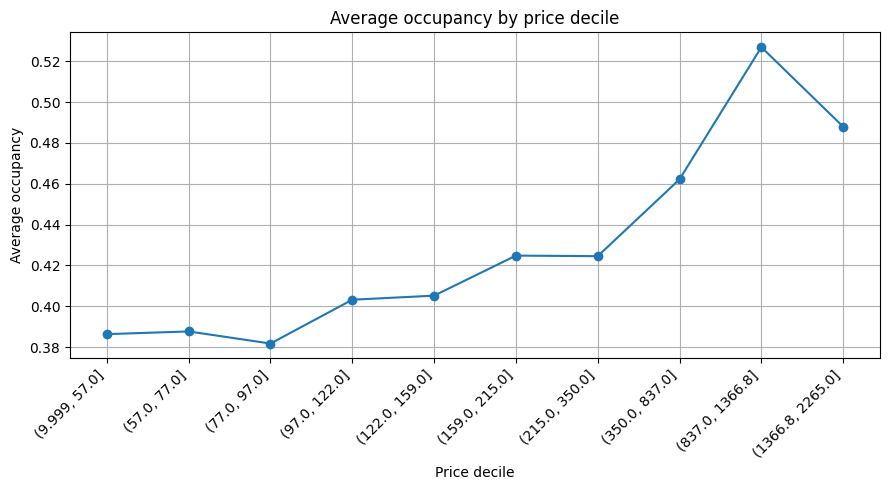

In [207]:

df_plot = df[['price', 'occupancy']].dropna().copy()
df_plot['price_decile'] = pd.qcut(df_plot['price'], 10, duplicates='drop')

price_occ = df_plot.groupby('price_decile', observed=False)['occupancy'].mean().reset_index()
price_occ['price_decile'] = price_occ['price_decile'].astype(str)

plt.figure(figsize=(9, 5))
plt.plot(price_occ['price_decile'], price_occ['occupancy'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Price decile')
plt.ylabel('Average occupancy')
plt.title('Average occupancy by price decile')
plt.grid(True)
plt.tight_layout()
plt.show()

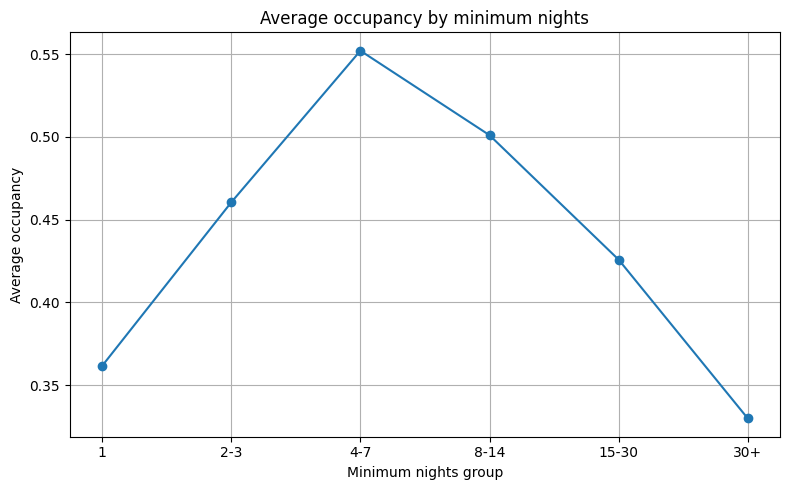

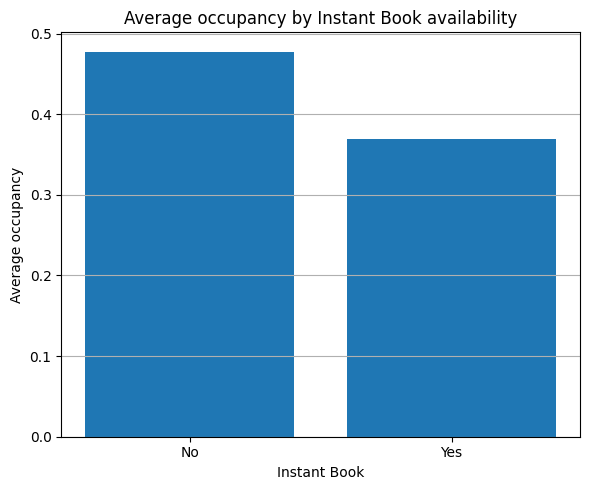

In [208]:

df_plot = df[['minimum_nights', 'instant_bookable', 'occupancy']].dropna().copy()

bins = [0, 1, 3, 7, 14, 30, df_plot['minimum_nights'].max()]
labels = ['1', '2-3', '4-7', '8-14', '15-30', '30+']
df_plot['min_nights_group'] = pd.cut(df_plot['minimum_nights'], bins=bins, labels=labels, include_lowest=True)

occ_by_min_nights = df_plot.groupby('min_nights_group', observed=False)['occupancy'].mean()

plt.figure(figsize=(8, 5))
plt.plot(occ_by_min_nights.index.astype(str), occ_by_min_nights.values, marker='o')
plt.xlabel('Minimum nights group')
plt.ylabel('Average occupancy')
plt.title('Average occupancy by minimum nights')
plt.grid(True)
plt.tight_layout()
plt.show()

instant_book_plot = df_plot.groupby('instant_bookable', observed=False)['occupancy'].mean().reset_index()
instant_book_plot['instant_bookable'] = instant_book_plot['instant_bookable'].map({0: 'No', 1: 'Yes'})

plt.figure(figsize=(6, 5))
plt.bar(instant_book_plot['instant_bookable'], instant_book_plot['occupancy'])
plt.xlabel('Instant Book')
plt.ylabel('Average occupancy')
plt.title('Average occupancy by Instant Book availability')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

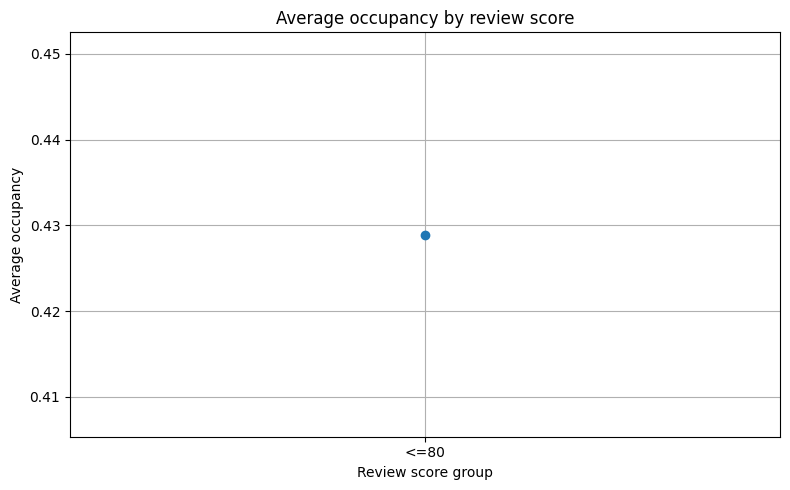

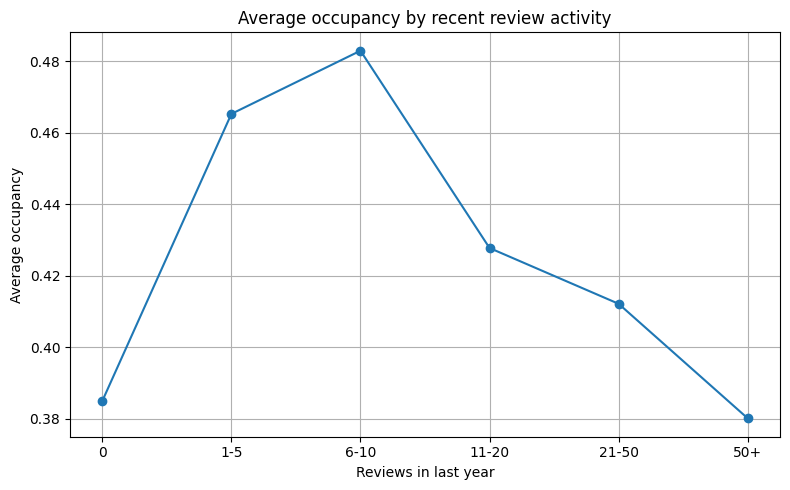

In [209]:
df_plot = df[['review_scores_rating', 'reviews_last_year', 'occupancy']].dropna().copy()

df_plot['rating_group'] = pd.cut(
    df_plot['review_scores_rating'],
    bins=[0, 80, 85, 90, 95, 100],
    labels=['<=80', '81-85', '86-90', '91-95', '96-100'],
    include_lowest=True
)

rating_occ = df_plot.groupby('rating_group', observed=False)['occupancy'].mean()

plt.figure(figsize=(8, 5))
plt.plot(rating_occ.index.astype(str), rating_occ.values, marker='o')
plt.xlabel('Review score group')
plt.ylabel('Average occupancy')
plt.title('Average occupancy by review score')
plt.grid(True)
plt.tight_layout()
plt.show()

df_plot['recent_reviews_group'] = pd.cut(
    df_plot['reviews_last_year'],
    bins=[-1, 0, 5, 10, 20, 50, df_plot['reviews_last_year'].max()],
    labels=['0', '1-5', '6-10', '11-20', '21-50', '50+'],
    include_lowest=True
)

recent_reviews_occ = df_plot.groupby('recent_reviews_group', observed=False)['occupancy'].mean()

plt.figure(figsize=(8, 5))
plt.plot(recent_reviews_occ.index.astype(str), recent_reviews_occ.values, marker='o')
plt.xlabel('Reviews in last year')
plt.ylabel('Average occupancy')
plt.title('Average occupancy by recent review activity')
plt.grid(True)
plt.tight_layout()
plt.show()